In [77]:
import json
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import RFECV, VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import PowerTransformer

os.makedirs("data/processed", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("config", exist_ok=True)

In [78]:
TRANSFORMS = {
    # Strong features
    "interaction_risk": "log1p",
    "toxicity_score": "log1p",
    "interaction_risk_rolling3_mean": "log1p",
    "threat_score": "log1p",
    "interaction_risk_ema3": "log1p",
    "toxicity_score_rolling3_mean": "log1p",
    "toxicity_score_ema3": "log1p",
    "interaction_risk_rolling3_max": "log1p",
    "toxicity_score_rolling3_max": "log1p",
    "mean_risk_so_far": "log1p",
    "max_toxicity_so_far": "log1p",
    "threat_score_rolling3_max": "log1p",
    "threat_score_ema3": "log1p",
    "threat_score_rolling3_mean": "log1p",
    "max_threat_so_far": "log1p",

    # Features benefiting from transformation
    "risk_slope_3": "yeo-johnson",
    "toxicity_diff": "square",
    "toxicity_accel": "square",
    "progressive_risk": "quantile",
    "threat_diff": "square",

    # Weak but useful
    "late_risk_increase": "log1p",
    "early_high_risk": "log1p",
    "state_input_similarity": "yeo-johnson",
    "drift_acceleration": "log1p",
    "long_term_state_similarity": "log1p",
    "prev_progressive": "log1p",
    "long_term_state_drift": "log1p",
    "pattern_risk_rolling3_mean": "log1p",
    "pattern_risk_ema3": "log1p",
    "pattern_risk_rolling3_max": "log1p",
    "state_input_distance": "log1p",

    # Binary transforms
    "state_similarity": "binarize",
    "topic_drift_score": "binarize",
    "pattern_risk": "binarize",
}

In [79]:
def conversation_split(df):
    all_conv_ids = df["conv_id"].unique()
    train_val_ids, test_ids = train_test_split(all_conv_ids, test_size=0.2, random_state=42, shuffle=True)
    train_ids, val_ids = train_test_split(train_val_ids, test_size=0.25, random_state=42, shuffle=True)

    train_df = df[df["conv_id"].isin(train_ids)].reset_index(drop=True)
    val_df = df[df["conv_id"].isin(val_ids)].reset_index(drop=True)
    test_df = df[df["conv_id"].isin(test_ids)].reset_index(drop=True)

    return {"train": train_df, "val": val_df, "test": test_df}


def remove_multicollinear(X_train, y_train, threshold):
    corr_df = X_train.copy()
    corr_df["target"] = y_train.values
    corr_matrix = corr_df.corr()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_remove = set()
    for col in upper.columns:
        if col == "target":
            continue
        highly_correlated = upper.index[abs(upper[col]) > threshold].tolist()
        for other_col in highly_correlated:
            if other_col == "target" or other_col in to_remove or col in to_remove:
                continue
            corr_col = abs(corr_matrix.loc[col, "target"])
            corr_other_col = abs(corr_matrix.loc[other_col, "target"])
            if corr_col >= corr_other_col:
                to_remove.add(other_col)
            else:
                to_remove.add(col)

    cols_to_keep = [c for c in X_train.columns if c not in to_remove]
    return cols_to_keep


def save_split(X, meta, y, path):
    out = X.copy()
    out["conv_id"] = meta["conv_id"].values
    out["turn_id"] = meta["turn_id"].values
    out["label"] = y.values
    out.to_csv(path, index=False)
    print(f"Saved {path}  shape={out.shape}")



def _apply_transform(series, transform):
    if transform == "log1p":
        return np.log1p(np.maximum(series, 0))

    if transform == "square":
        return np.square(series)

    if transform == "binarize":
        return (series > 0).astype(float)

    if transform == "yeo-johnson":
        pt = PowerTransformer(method="yeo-johnson", standardize=False)
        return pt.fit_transform(
            np.asarray(series).reshape(-1, 1)
        ).flatten()
    
    

    return series


def apply_transform(df):
    df = df.copy()
    for feature, transform in TRANSFORMS.items():
        if feature not in df.columns:
            continue
        df[f"{feature}"] = _apply_transform(df[feature], transform)
    return df

In [80]:

train_df= pd.read_csv("../data/pca/train2.csv")
val_df= pd.read_csv("../data/pca/val2.csv")
test_df= pd.read_csv("../data/pca/test2.csv")



embedding_cols = [c for c in train_df.columns if c.strip().isdigit()]



print(f"Excluding {len(embedding_cols)} embedding columns")

feature_cols = [c for c in train_df.columns if c not in embedding_cols]

# train_df_trans = apply_transform(train_df[feature_cols])
# val_df_trans = apply_transform(val_df[feature_cols])
# test_df_trans = apply_transform(test_df[feature_cols])

train_df_trans = train_df[feature_cols]
val_df_trans = val_df[feature_cols]
test_df_trans = test_df[feature_cols]

feature_cols = [c for c in train_df_trans.columns if c not in ["conv_id", "turn_id", "label"]]

meta_train= train_df[["conv_id","turn_id"]]
meta_val= val_df[["conv_id","turn_id"]]
meta_test= test_df[["conv_id","turn_id"]]

X_train= train_df_trans[feature_cols]
X_val= val_df_trans[feature_cols]
X_test= test_df_trans[feature_cols]

y_train= train_df["label"]
y_val= val_df["label"]
y_test= test_df["label"]

Excluding 348 embedding columns


In [81]:
corr_vals = X_train.corrwith(y_train).abs().sort_values(ascending=False)
corr_vals

state_input_similarity            0.123826
pattern_risk_ema3                 0.094240
pattern_risk_rolling3_mean        0.093904
pattern_risk_rolling3_max         0.090372
pattern_risk                      0.076031
drift_acceleration                0.075416
progressive_risk                  0.074606
threat_score                      0.071011
threat_score_rolling3_max         0.064335
late_risk_increase                0.064207
prev_progressive                  0.060471
max_threat_so_far                 0.060456
threat_score_ema3                 0.058819
state_input_distance              0.057210
interaction_risk_rolling3_max     0.056846
toxicity_score_rolling3_max       0.056312
interaction_risk                  0.055201
max_toxicity_so_far               0.054806
threat_score_rolling3_mean        0.054605
toxicity_score                    0.054440
threat_diff                       0.052730
risk_growth_ratio                 0.049317
risk_slope_3                      0.046969
long_term_s

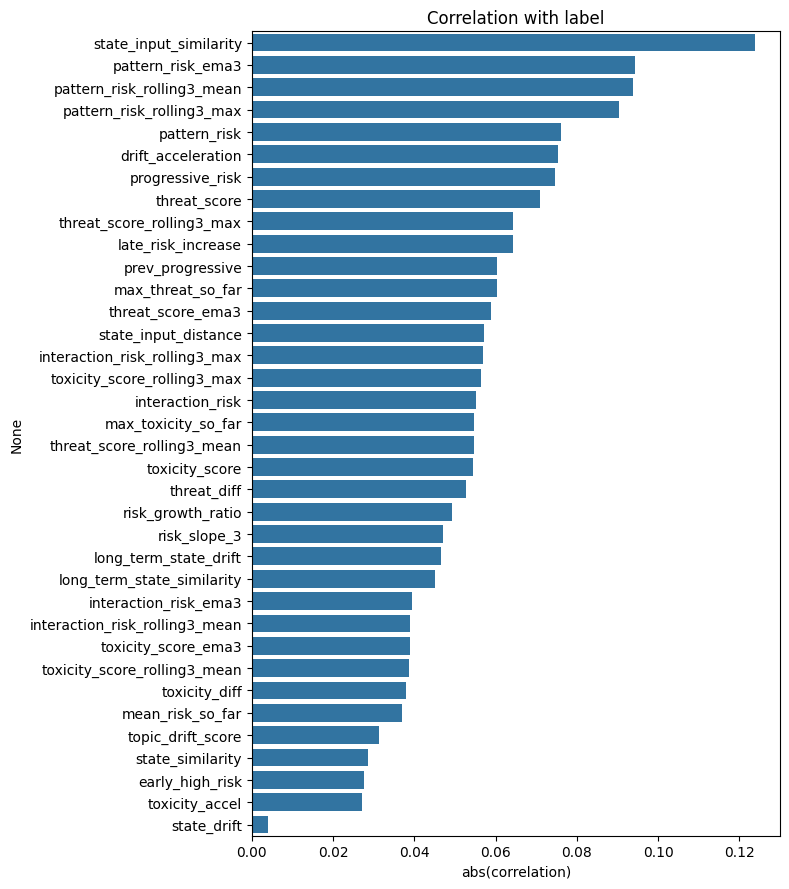

In [82]:
plt.figure(figsize=(8, max(4, len(corr_vals) * 0.25)))
sns.barplot(x=corr_vals.values, y=corr_vals.index)
plt.title("Correlation with label")
plt.xlabel("abs(correlation)")
plt.tight_layout()
plt.show()

In [83]:
# scaler = RobustScaler()
# X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
# X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=feature_cols)
# X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)
# joblib.dump(scaler, "../models/scaler.pkl")
# X_train_scaled.head()

X_train_scaled = X_train[feature_cols]
X_val_scaled = X_val[feature_cols]
X_test_scaled = X_test[feature_cols]

In [84]:
var_sel = VarianceThreshold(threshold=0.005)
var_sel.fit(X_train_scaled)
var_cols = X_train_scaled.columns[var_sel.get_support()].tolist()
X_train_var = pd.DataFrame(var_sel.transform(X_train_scaled), columns=var_cols)
X_val_var = pd.DataFrame(var_sel.transform(X_val_scaled), columns=var_cols)
X_test_var = pd.DataFrame(var_sel.transform(X_test_scaled), columns=var_cols)
print(f"After variance filter: {len(var_cols)}")
var_cols

After variance filter: 22


['state_drift',
 'long_term_state_drift',
 'state_similarity',
 'long_term_state_similarity',
 'topic_drift_score',
 'drift_acceleration',
 'interaction_risk',
 'pattern_risk',
 'toxicity_score_rolling3_max',
 'interaction_risk_ema3',
 'interaction_risk_rolling3_mean',
 'interaction_risk_rolling3_max',
 'pattern_risk_ema3',
 'pattern_risk_rolling3_mean',
 'pattern_risk_rolling3_max',
 'toxicity_accel',
 'risk_slope_3',
 'max_toxicity_so_far',
 'mean_risk_so_far',
 'early_high_risk',
 'late_risk_increase',
 'risk_growth_ratio']

In [85]:
corr_vals = X_train_var.corrwith(y_train).abs().sort_values(ascending=False)
corr_vals

pattern_risk_ema3                 0.094240
pattern_risk_rolling3_mean        0.093904
pattern_risk_rolling3_max         0.090372
pattern_risk                      0.076031
drift_acceleration                0.075416
late_risk_increase                0.064207
interaction_risk_rolling3_max     0.056846
toxicity_score_rolling3_max       0.056312
interaction_risk                  0.055201
max_toxicity_so_far               0.054806
risk_growth_ratio                 0.049317
risk_slope_3                      0.046969
long_term_state_drift             0.046628
long_term_state_similarity        0.045072
interaction_risk_ema3             0.039421
interaction_risk_rolling3_mean    0.039047
mean_risk_so_far                  0.036872
topic_drift_score                 0.031399
state_similarity                  0.028492
early_high_risk                   0.027734
toxicity_accel                    0.027204
state_drift                       0.003875
dtype: float64

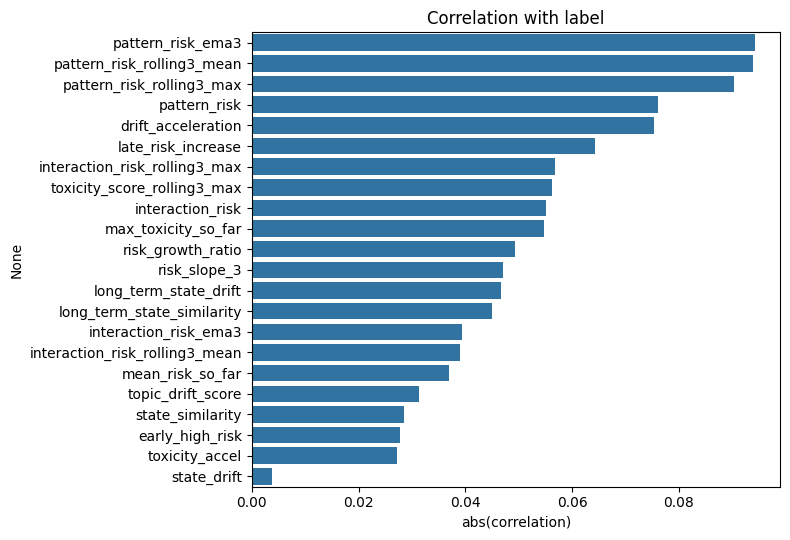

In [86]:
plt.figure(figsize=(8, max(4, len(corr_vals) * 0.25)))
sns.barplot(x=corr_vals.values, y=corr_vals.index)
plt.title("Correlation with label")
plt.xlabel("abs(correlation)")
plt.tight_layout()
plt.show()

In [87]:
corr_cols = corr_vals[corr_vals > 0.005].index.tolist()
X_train_corr = X_train_var[corr_cols]
X_val_corr = X_val_var[corr_cols]
X_test_corr = X_test_var[corr_cols]
print(f"After correlation filter: {len(corr_cols)}")

After correlation filter: 21


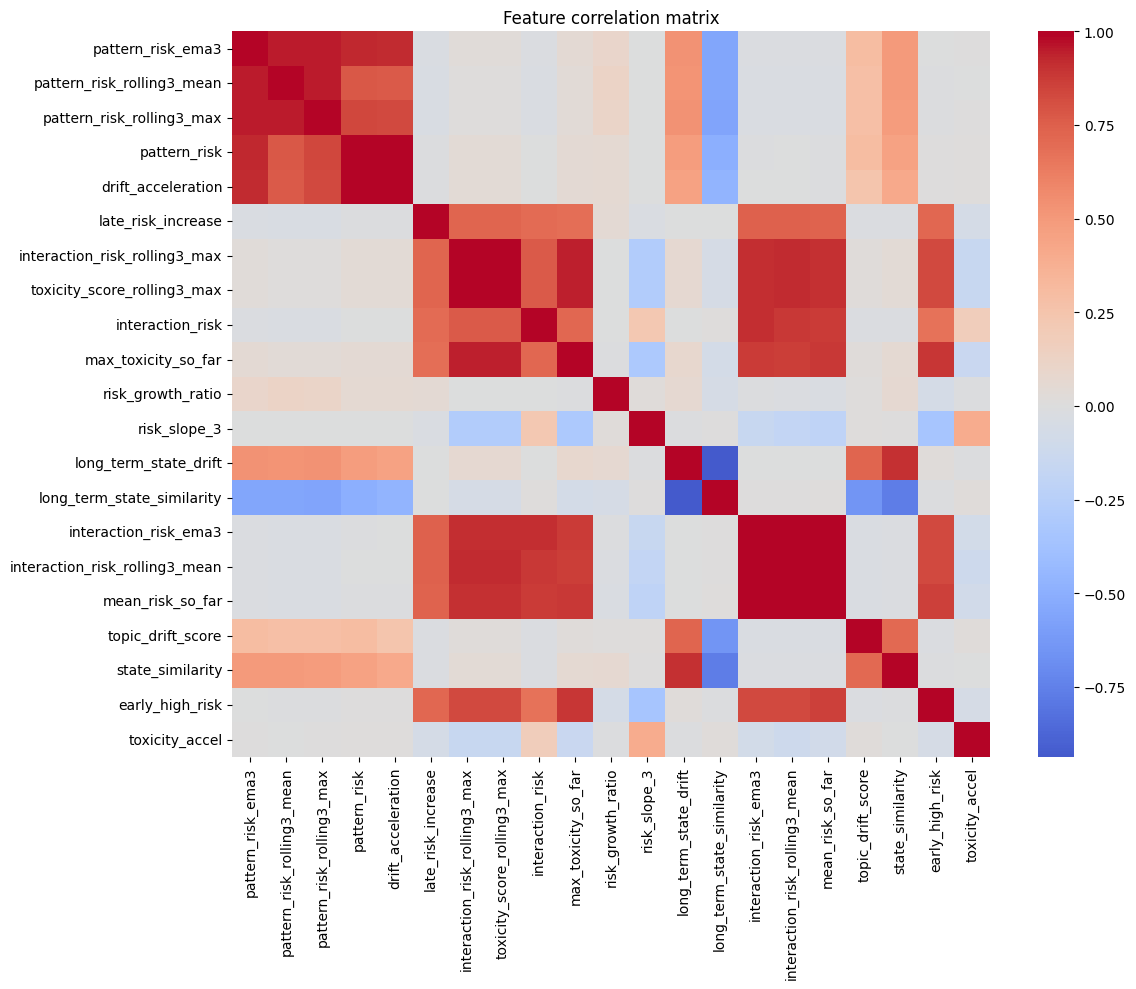

In [88]:
corr_matrix = X_train_corr.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

In [89]:
mc_cols = remove_multicollinear(X_train_corr, y_train, 0.9)
X_train_final = X_train_corr[mc_cols]
X_val_final = X_val_corr[mc_cols]
X_test_final = X_test_corr[mc_cols]
print(f"After multicollinearity: {len(mc_cols)}")
mc_cols

After multicollinearity: 10


['pattern_risk_ema3',
 'late_risk_increase',
 'interaction_risk_rolling3_max',
 'interaction_risk',
 'risk_growth_ratio',
 'risk_slope_3',
 'long_term_state_drift',
 'topic_drift_score',
 'early_high_risk',
 'toxicity_accel']

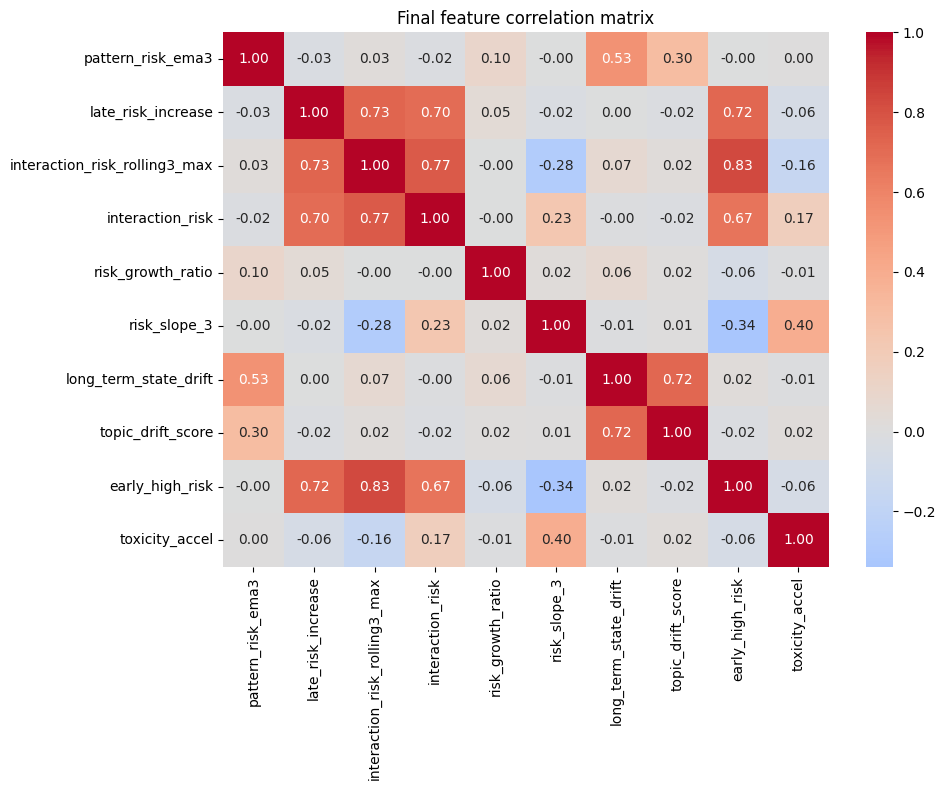

In [90]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train_final.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Final feature correlation matrix")
plt.tight_layout()
plt.show()

In [91]:
# scaler = RobustScaler()
# X_train_final = pd.DataFrame(scaler.fit_transform(X_train_final))
# X_val_final = pd.DataFrame(scaler.transform(X_val_final))
# X_test_final = pd.DataFrame(scaler.transform(X_test_final))
# joblib.dump(scaler, "../models/scaler.pkl")
# X_train_final.head()


In [92]:

X_train_final= pd.concat([X_train_final, train_df[embedding_cols]], axis=1)
X_val_final= pd.concat([X_val_final, val_df[embedding_cols]], axis=1)
X_test_final= pd.concat([X_test_final, test_df[embedding_cols]], axis=1)

save_split(X_train_final, meta_train, y_train, "../data/processed/train2.csv")
save_split(X_val_final, meta_val, y_val, "../data/processed/validation2.csv")
save_split(X_test_final, meta_test, y_test, "../data/processed/test2.csv")

with open("../config/feature_info.json", "w") as f:
    json.dump({"selected_features": mc_cols, "scaler_path": "../models/scaler2.pkl"}, f, indent=4)

print(f"\nOriginal: {len(feature_cols)}  Final: {len(mc_cols)}")

Saved ../data/processed/train2.csv  shape=(2636, 361)
Saved ../data/processed/validation2.csv  shape=(293, 361)
Saved ../data/processed/test2.csv  shape=(326, 361)

Original: 36  Final: 10


In [93]:
X_train.isnull().sum()

state_drift                       0
state_input_distance              0
long_term_state_drift             0
state_similarity                  0
state_input_similarity            0
long_term_state_similarity        0
toxicity_score                    0
threat_score                      0
topic_drift_score                 0
drift_acceleration                0
interaction_risk                  0
pattern_risk                      0
progressive_risk                  0
prev_progressive                  0
toxicity_score_ema3               0
toxicity_score_rolling3_mean      0
toxicity_score_rolling3_max       0
threat_score_ema3                 0
threat_score_rolling3_mean        0
threat_score_rolling3_max         0
interaction_risk_ema3             0
interaction_risk_rolling3_mean    0
interaction_risk_rolling3_max     0
pattern_risk_ema3                 0
pattern_risk_rolling3_mean        0
pattern_risk_rolling3_max         0
toxicity_diff                     0
threat_diff                 

In [94]:
df= pd.read_csv("../data/pca/train2.csv")

In [95]:
df.isnull().sum()

0                     0
1                     0
2                     0
3                     0
4                     0
                     ..
mean_risk_so_far      0
early_high_risk       0
late_risk_increase    0
risk_growth_ratio     0
label                 0
Length: 387, dtype: int64